# makemore Part 3: Activations, Gradients, and Batch Normalization

These exercises follow the chronological flow of the **makemore Part 3: Activations, Gradients, and Batch Normalization** video and the notebook [makemore/makemore_part3_bn.ipynb](../makemore/makemore_part3_bn.ipynb). Work through them in order to re-create the notebook from scratch.

---

## Part 1: Setup and Baseline MLP

### Exercise 1: Imports, Data, and Vocabulary

Write the setup code:
- Import `torch`, `torch.nn.functional as F`, and `matplotlib.pyplot as plt`. Enable inline plotting.
- Load the names file and store all words in a Python list.
- Build character-level `stoi` and `itos` mappings, reserving index `0` for the special `'.'` token. Store the total number of distinct tokens as `vocab_size`.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

bands = open('data/band_names.txt').read().splitlines()

In [2]:
chars = sorted(list(set(''.join(bands))))

stoi = {s : i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i : s for s, i in stoi.items()}

n_chars = len(stoi)

<details><summary>💡 Solution — click to expand</summary>

```python
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('data/names.txt', 'r').read().splitlines()
print(words[:8])
print(len(words))

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)
```

</details>

### Exercise 2: Dataset Builder and Train / Dev / Test Split

Create a function `build_dataset(words)` that:
- Uses `block_size = 3` as the context window.
- Rolls a context of `[0] * block_size` through each word (including the terminating `'.'` character), appending `(context, next_char_index)` pairs to lists `X` and `Y`.
- Returns `(torch.tensor(X), torch.tensor(Y))` and prints their shapes.

Then create the 80 / 10 / 10 splits:
- Shuffle the words with `random.seed(42)`.
- Split into `Xtr/Ytr`, `Xdev/Ydev`, `Xte/Yte`.

In [3]:
block_size = 4

def build_dataset(words):
    X, Y = [], []
    for word in words: 
        ctx = block_size*[0]
        for ch in word + '.':
            ix = stoi[ch]
            X.append(ctx)
            Y.append(ix)
            ctx = ctx[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(bands)

n1 = int(0.8 * len(bands))
n2 = int(0.9 * len(bands))

Xtr, Ytr = build_dataset(bands[:n1])
Xdev, Ydev = build_dataset(bands[n1:n2])
Xte, Yte = build_dataset(bands[n2:])

<details><summary>💡 Solution — click to expand</summary>

```python
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])
```

</details>

### Exercise 3: MLP Parameters and Evaluation Utility

Initialize the baseline MLP:
- Use `n_embd = 10`, `n_hidden = 200`.
- Create a fixed `torch.Generator` with seed `2147483647`.
- Initialize parameters:
  - `C` — embedding table of shape `(vocab_size, n_embd)`.
  - `W1` of shape `(n_embd * block_size, n_hidden)`, `b1` of shape `(n_hidden,)`.
  - `W2` of shape `(n_hidden, vocab_size)`, `b2` of shape `(vocab_size,)`.
- Print the total parameter count.

Write a `split_loss(split)` function (decorated with `@torch.no_grad()`) that:
- Accepts `'train'`, `'val'`, or `'test'` as a string.
- Performs a full forward pass: embed → flatten → linear + bias → tanh → linear + bias → cross-entropy loss.
- Prints the split name and loss value.

In [5]:
g = torch.Generator().manual_seed(5390438945)

# parameters
n_embeds = 12
n_hidden = 400

# embeddings
C = torch.randn((n_chars,n_embeds), requires_grad=True, generator = g)

# hidden layer
W1 = torch.randn((n_embeds*block_size, n_hidden), requires_grad=True, generator=g)
b1 = torch.randn(n_hidden, requires_grad=True, generator=g)

# output layer
W2 = torch.randn((n_hidden, n_chars), requires_grad=True, generator=g)
b2 = torch.randn(n_chars, requires_grad=True, generator=g)

parameters = [C, W1, b1, W2, b2]
n_params = sum(p.nelement() for p in parameters)
n_params

46032

In [6]:
@torch.no_grad()
def calc_loss(split):
    x, y = {'train': (Xtr, Ytr), 'dev': (Xdev, Ydev), 'test':(Xte, Yte)}[split]
    emb = C[x]
    h = torch.tanh(emb.view(-1, n_embeds*block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(loss.item())

calc_loss('train')
calc_loss('dev')

44.06918716430664
44.07744598388672


<details><summary>💡 Solution — click to expand</summary>

```python
n_embd   = 10
n_hidden = 200
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    emb    = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h      = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss   = F.cross_entropy(logits, y)
    print(split, loss.item())
```

</details>

---

## Part 2: Diagnosing a Bad Initialization — Overconfident Output Layer

### Exercise 4: Observing the Hockey-Stick Loss

Run the training loop for 200,000 steps with standard random initialization, using batch size 32 and the piecewise learning rate schedule (`lr=0.1` for the first 100,000 steps, then `lr=0.01`), tracking the log₁₀ loss in a list `lossi`.

- Plot `lossi` and note the pronounced "hockey-stick" shape at the beginning of training.
- Print the loss at iteration 0 and compare it to the theoretically expected loss for a uniform 27-class distribution (i.e., `-log(1/27) ≈ 3.29`).

In [ ]:
n_steps = 400000
batch_size = 64

lossi = []
stepi = torch.arange(0, n_steps, 1)

In [24]:
for i in range(n_steps):

    # mini-batch construct 
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    # forward pass 
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, n_embeds*block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    lossi.append(loss.log10().item())

    if i % 5000 == 0:
        print(f'{i}/{n_steps} : {loss}')

    # backward pass
    for p in parameters:
        p.grad = None
    
    loss.backward()

    # update
    lr = 0.1 if i < n_steps/2 else 0.01 
    for p in parameters:
        p.data += -lr * p.grad

0/200000 : 39.27888107299805
5000/200000 : 3.1235897541046143
10000/200000 : 2.7413978576660156
15000/200000 : 2.8986363410949707
20000/200000 : 2.9263646602630615
25000/200000 : 2.498565435409546
30000/200000 : 2.565148115158081
35000/200000 : 2.3464112281799316
40000/200000 : 2.3534860610961914
45000/200000 : 2.243253707885742
50000/200000 : 2.641634941101074
55000/200000 : 2.3777687549591064
60000/200000 : 2.667520523071289
65000/200000 : 3.2014176845550537
70000/200000 : 3.000631809234619
75000/200000 : 2.3760321140289307
80000/200000 : 2.707280158996582
85000/200000 : 2.592700242996216
90000/200000 : 2.473607063293457
95000/200000 : 2.4225263595581055
100000/200000 : 2.4358043670654297
105000/200000 : 2.9046664237976074
110000/200000 : 1.9350091218948364
115000/200000 : 2.0741779804229736
120000/200000 : 2.3142523765563965
125000/200000 : 2.0731465816497803
130000/200000 : 2.417572021484375
135000/200000 : 2.1475987434387207
140000/200000 : 2.44145131111145
145000/200000 : 2.13529

In [19]:
calc_loss('train')
calc_loss('dev')

2.3209569454193115
2.347132921218872


In [26]:
import math
-math.log(1/n_chars) # uniform loss expected in the first pass

4.1588830833596715

<details><summary>💡 Solution — click to expand</summary>

When all network weights are initialized from N(0,1) at full scale, the logits that emerge from the output layer take on large, arbitrary values. The softmax then turns these into very peaky distributions that confidently assign high probability to whichever class has the highest logit — almost certainly the wrong one. The expected loss for a perfectly uniform 27-class distribution is −log(1/27) ≈ 3.29, but with badly-scaled logits the network records losses of 20–30 at step 0. The optimizer must first spend thousands of steps simply shrinking the output weights before it can do any useful learning — that is the "hockey stick": a rapid early drop followed by slow, productive improvement.

```python
lossi = []
max_steps = 200000
batch_size = 32

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb    = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    h      = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss   = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

plt.plot(lossi)

import math
print(-math.log(1/27))   # expected ≈ 3.2958
```

</details>

### Exercise 5: Fixing the Output-Layer Initialization

Explain why the initial loss is so high and fix the initialization:
- Scale `W2` down by a factor of `0.01` so that the initial logits are near zero.
- Set `b2` to exactly zero at initialization.
- Re-run training and verify that:
  - The initial loss is now close to the expected value (~3.29).
  - The hockey-stick shape disappears from the loss curve.
  - The final validation loss improves compared to the original baseline.

In [12]:
g = torch.Generator().manual_seed(5390438945)

# parameters
n_embeds = 12
n_hidden = 400

# embeddings
C = torch.randn((n_chars, n_embeds), generator=g)

# hidden layer
W1 = torch.randn((n_embeds*block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)

# output layer: scale down W2 and zero b2 to fix overconfident initialization
W2 = torch.randn((n_hidden, n_chars), generator=g) * 0.01
b2 = torch.zeros(n_chars)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

n_params = sum(p.nelement() for p in parameters)
n_params


46032

In [13]:
n_steps = 400000
batch_size = 64

for i in range(n_steps):

    # mini-batch construct 
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    # forward pass 
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, n_embeds*block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    if i % 50000 == 0:
        print(f'{i}/{n_steps} : {loss.item()}')

    # backward pass
    for p in parameters:
        p.grad = None
    
    loss.backward()

    # update
    lr = 0.1 if i < n_steps/2 else 0.01 
    for p in parameters:
        p.data += -lr * p.grad

0/400000 : 4.153388023376465
50000/400000 : 2.389298439025879
100000/400000 : 2.549149990081787
150000/400000 : 2.128298759460449
200000/400000 : 2.39979887008667
250000/400000 : 2.068099021911621
300000/400000 : 2.0219805240631104
350000/400000 : 2.165559768676758


In [14]:
calc_loss('train')
calc_loss('dev')

2.07363224029541
2.1141839027404785


<details><summary>💡 Solution — click to expand</summary>

The logits equal `h @ W2 + b2`. For logits to start near zero, `b2` should be initialized to zero and `W2` should be small so that the product `h @ W2` is also close to zero. Scaling `W2 * 0.01` and zeroing `b2` ensures that all class logits start approximately equal, giving a near-uniform output distribution and the expected initial loss. After retraining, the initial loss is ~3.3 and the loss curve shows no hockey stick. The final validation loss improves from ~2.17 to ~2.13.

```python
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01   # scaled down
b2 = torch.randn(vocab_size,                      generator=g) * 0      # zeroed

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

# re-run the same training loop from Exercise 4
```

</details>

---

## Part 3: Diagnosing a Bad Initialization — Saturated Tanh Hidden Layer

### Exercise 6: Visualizing Tanh Saturation

After re-initializing the network (with the `W2` fix from Exercise 5 but default `W1` / `b1`), break after the very first forward pass and inspect the hidden pre-activations and activations:
- Plot a histogram of the pre-activations `hpreact` (50 bins). Report the approximate range.
- Plot a histogram of `h = torch.tanh(hpreact)`. How much of the distribution is concentrated near ±1?
- Visualize which neurons are "saturated" by displaying, as a 2-D image, the boolean tensor `h.abs() > 0.99`. Describe what you observe.

Explain the gradient-vanishing consequence: why does a tanh unit whose output is close to ±1 prevent useful gradient flow during backpropagation?

In [32]:
g = torch.Generator().manual_seed(5390438945)

# parameters
n_embeds = 12
n_hidden = 400

# embeddings
C = torch.randn((n_chars, n_embeds), generator=g)

# hidden layer
W1 = torch.randn((n_embeds*block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)

# output layer: scale down W2 and zero b2 to fix overconfident initialization
W2 = torch.randn((n_hidden, n_chars), generator=g) * 0.01
b2 = torch.zeros(n_chars)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

n_params = sum(p.nelement() for p in parameters)
n_params


46032

In [33]:
batch_size = 64

calc_loss('train')
calc_loss('dev')

4.179737567901611
4.179588317871094


In [34]:
ix = torch.randint(0, Xtr.shape[0], (batch_size,))
emb = C[Xtr[ix]]
hpreact = emb.view(-1, n_embeds*block_size) @ W1 + b1
h = torch.tanh(hpreact)
#logits = h @ W2 + b2

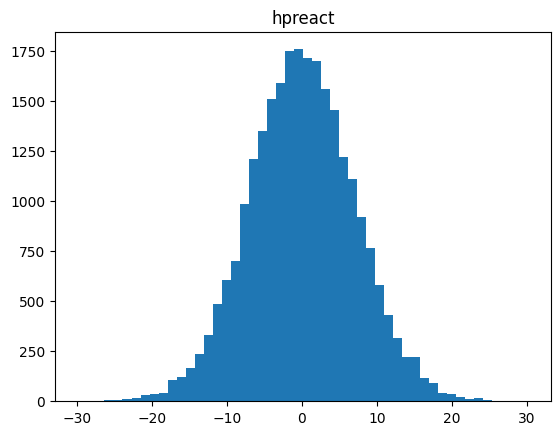

In [23]:
plt.hist(hpreact.view(-1).tolist(), 50); plt.title('hpreact'); plt.show()

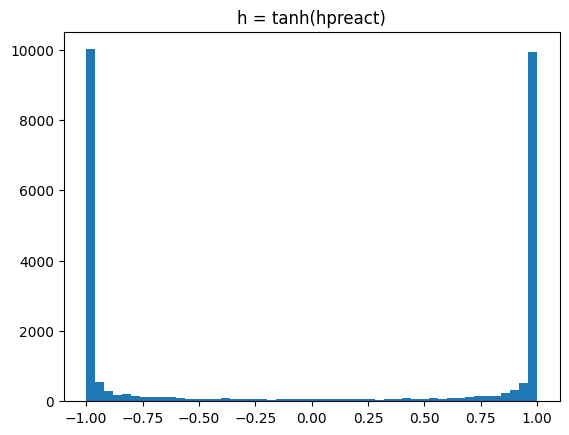

In [24]:
plt.hist(h.view(-1).tolist(), 50); plt.title('h = tanh(hpreact)'); plt.show()

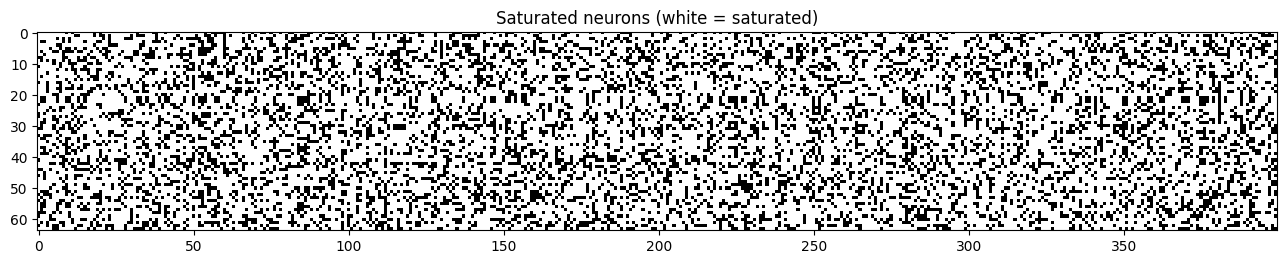

In [35]:
plt.figure(figsize=(16, 3))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')
plt.title('Saturated neurons (white = saturated)'); plt.show()

In [41]:
(h.abs() > 0.95).all(dim = 0).sum()

tensor(0)

<details><summary>💡 Solution — click to expand</summary>

When the pre-activations span large ranges (e.g., −15 to +15), almost all outputs of `tanh` are pushed to ±1 — the flat regions. The local gradient of `tanh` at a value `t` is `1 − t²`. When `t ≈ ±1`, this is `≈ 0`, so the gradient of the loss with respect to all weights and biases feeding into that neuron is multiplied by nearly zero. The neuron effectively stops learning: it is *saturated* or *dead*. A neuron is entirely dead when every training example saturates it — visible as an all-white column in the saturation map.

```python
# Use a single mini-batch to inspect
batch_size = 32
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

emb     = C[Xb]
embcat  = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h       = torch.tanh(hpreact)

# Histogram of pre-activations
plt.hist(hpreact.view(-1).tolist(), 50); plt.title('hpreact'); plt.show()

# Histogram of tanh outputs
plt.hist(h.view(-1).tolist(), 50); plt.title('h = tanh(hpreact)'); plt.show()

# Saturation map
plt.figure(figsize=(16, 3))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')
plt.title('Saturated neurons (white = saturated)'); plt.show()
```

</details>

### Exercise 7: Fixing the Hidden-Layer Initialization

Make the pre-activations approximately Gaussian at initialization by scaling `W1` and `b1`:
- Multiply `W1` by `0.2` and `b1` by `0.01`.
- Re-run only the first forward pass and re-plot the histograms of `hpreact` and `h`.
- Verify that the saturation image is now nearly all dark (few saturated neurons).
- Run full training and confirm that the validation loss improves relative to the Exercise 5 baseline.

In [26]:
g = torch.Generator().manual_seed(5390438945)

# parameters
n_embeds = 12
n_hidden = 400

# embeddings
C = torch.randn((n_chars, n_embeds), generator=g)

# hidden layer
W1 = torch.randn((n_embeds*block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.1

# output layer: scale down W2 and zero b2 to fix overconfident initialization
W2 = torch.randn((n_hidden, n_chars), generator=g) * 0.01
b2 = torch.zeros(n_chars)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

n_params = sum(p.nelement() for p in parameters)
n_params

46032

In [28]:
ix = torch.randint(0, Xtr.shape[0], (batch_size,))
emb = C[Xtr[ix]]
hpreact = emb.view(-1, n_embeds*block_size) @ W1 + b1
h = torch.tanh(hpreact)

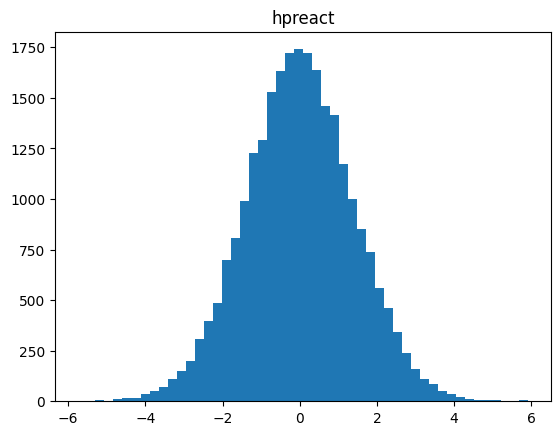

In [29]:
plt.hist(hpreact.view(-1).tolist(), 50); plt.title('hpreact'); plt.show()

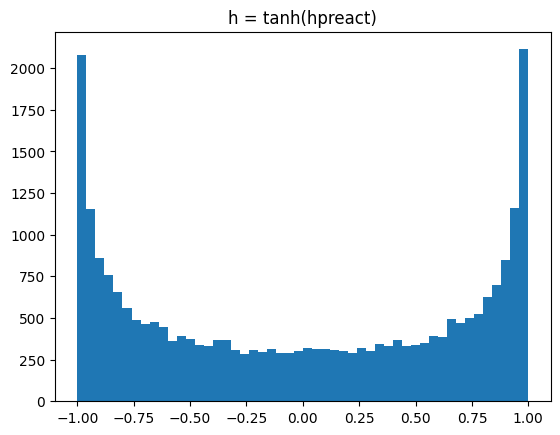

In [30]:
plt.hist(h.view(-1).tolist(), 50); plt.title('h = tanh(hpreact)'); plt.show()

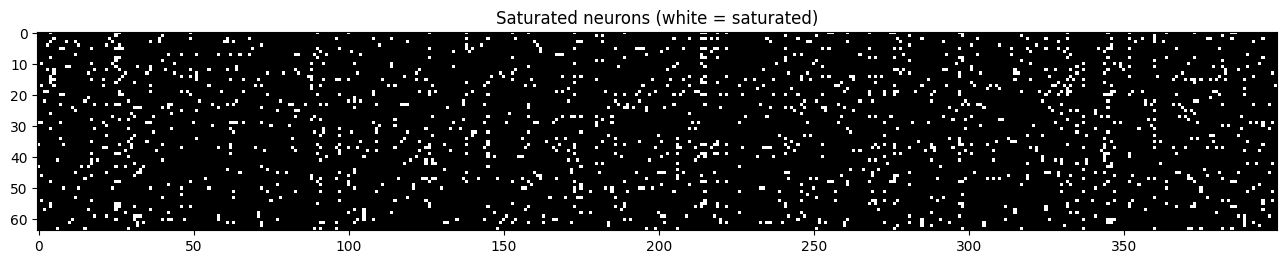

In [31]:
plt.figure(figsize=(16, 3))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')
plt.title('Saturated neurons (white = saturated)'); plt.show()

<details><summary>💡 Solution — click to expand</summary>

With a smaller scale, the pre-activations are roughly in the range [−1.5, 1.5], which is the active (non-saturating) region of `tanh`. The saturation map is nearly all dark because no neuron is stuck in the flat tails. This means gradients can flow freely through every neuron during backpropagation, leading to more efficient training. Final validation loss improves to ~2.10.

```python
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2    # scaled
b1 = torch.randn(n_hidden,                        generator=g) * 0.01   # small
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

# re-run the training loop and call split_loss('val') at the end
```

</details>

---

## Part 4: Principled Weight Initialization

### Exercise 8: The Fan-In Scaling Rule

Introduce the concept of preserving activation variance through gain / √(fan_in) scaling:
- Create a toy example: draw `x` of shape `(1000, 10)` and `w` of shape `(10, 200)` from N(0,1).
- Compute `y = x @ w` and print the standard deviation of `y`. Explain why it differs from 1.
- Divide `w` by `fan_in**0.5` (where `fan_in = 10`) and recompute `y`. Verify the std is now close to 1.
- Explain intuitively why dividing by √(fan_in) keeps the variance of the output the same as the input.

In [ ]:
x = torch.randn((1000, 10))
w = torch.randn((10,200))
y = x @ w 
y.std()

tensor(3.1103)

In [43]:
w = w / (10**0.5)
y = x @ w 

In [44]:
y.std()

tensor(0.9836)

<details><summary>💡 Solution — click to expand</summary>

Each output neuron is a sum of `fan_in = 10` independent products. The variance of each product is `Var(x_i) * Var(w_i) = 1 * 1 = 1`, and because there are 10 such independent terms, the total variance is 10, giving std = √10 ≈ 3.16. Dividing `w` by √(fan_in) rescales each term so that the total variance stays at 1. This is the key principle behind principled weight initialization: scale weights so that the variance of activations is preserved through each layer, preventing them from exploding or collapsing.

```python
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
y = x @ w
print('before scaling: std =', y.std().item())   # ≈ 3.16 = sqrt(10)

w /= 10**0.5
y = x @ w
print('after scaling:  std =', y.std().item())   # ≈ 1.0
```

</details>

### Exercise 9: Kaiming (He) Initialization for Tanh

Apply the principled initialization to the MLP:
- Compute `fan_in = n_embd * block_size` for `W1`.
- Initialize `W1` with the Kaiming formula for a tanh nonlinearity: multiply the default N(0,1) by `(5/3) / fan_in**0.5` (gain = 5/3 for tanh, as recommended in the He et al. paper).
- Remove the explicit `b1` parameter (comment it out) and omit it from the forward pass.
- Keep `W2` scaled by `0.01` and `b2 = 0`.
- Run full training and confirm the validation loss is in the same range as the hand-tuned scaling from Exercise 7, but without requiring any manual inspection of histograms.

In [6]:
g = torch.Generator().manual_seed(5390438945)

# parameters
n_embeds = 12
n_hidden = 400
fan_in = n_embeds * block_size

# embeddings
C = torch.randn((n_chars, n_embeds), generator=g)

# hidden layer
W1 = torch.randn((fan_in, n_hidden), generator=g) * (5/3 / fan_in**2)
#b1 = torch.randn(n_hidden, generator=g) * 0.1

# output layer: scale down W2 and zero b2 to fix overconfident initialization
W2 = torch.randn((n_hidden, n_chars), generator=g) * 0.01
b2 = torch.zeros(n_chars)

parameters = [C, W1, W2, b2]
for p in parameters:
    p.requires_grad = True

n_params = sum(p.nelement() for p in parameters)
n_params

45632

In [7]:
@torch.no_grad()
def calc_loss(split):
    x, y = {'train': (Xtr, Ytr), 'dev': (Xdev, Ydev), 'test':(Xte, Yte)}[split]
    emb = C[x]
    h = torch.tanh(emb.view(-1, n_embeds*block_size) @ W1 )
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(loss.item())

calc_loss('train')
calc_loss('dev')

4.158904552459717
4.158905029296875


<details><summary>💡 Solution — click to expand</summary>

The `tanh` nonlinearity is a *contractive* function: it squeezes its input distribution, effectively reducing variance. To compensate, the Kaiming formula multiplies the fan-in normalization by a *gain* of 5/3 (empirically determined for tanh in the He et al. 2015 paper). The formula is σ_W = gain / √(fan_in) = (5/3) / √(n_embd × block_size). This ensures that, even after the tanh squishing, activations remain roughly unit-variance throughout the network depth — without needing to manually inspect histograms.

```python
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
# b1 omitted
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, W2, b2]
for p in parameters:
    p.requires_grad = True

# run training loop (forward pass uses: h = torch.tanh(embcat @ W1), no b1)
```

</details>

---

## Part 5: Batch Normalization

### Exercise 10: Implementing Batch Normalization from Scratch

Add a batch normalization layer between the linear pre-activations and the tanh nonlinearity:
- After computing `hpreact = embcat @ W1`, normalize it across the batch dimension:
  - Compute `bnmeani = hpreact.mean(0, keepdim=True)` and `bnstdi = hpreact.std(0, keepdim=True)`.
  - Normalize: `hpreact = (hpreact - bnmeani) / bnstdi`.
- Add learnable scale and shift parameters:
  - `bngain` of shape `(1, n_hidden)` initialized to ones.
  - `bnbias` of shape `(1, n_hidden)` initialized to zeros.
  - Apply them: `hpreact = bngain * hpreact + bnbias`.
- Include `bngain` and `bnbias` in the `parameters` list.
- Explain why the `b1` bias term (if retained) is now redundant and should be removed.

In [29]:
g = torch.Generator().manual_seed(5390438945)

# parameters
n_embeds = 15
n_hidden = 500
fan_in = n_embeds * block_size

# embeddings
C = torch.randn((n_chars, n_embeds), generator=g)

# hidden layer
W1 = torch.randn((fan_in, n_hidden), generator=g) * (5/3 / fan_in**2)

# batch normalization layer
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

# output layer: scale down W2 and zero b2 to fix overconfident initialization
W2 = torch.randn((n_hidden, n_chars), generator=g) * 0.01
b2 = torch.zeros(n_chars)

parameters = [C, W1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

n_params = sum(p.nelement() for p in parameters)
n_params

64024

In [30]:
n_steps = 400000
batch_size = 64

for i in range(n_steps):
    
    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    # forward pass
    emb = C[Xtr[ix]]
    hpreact = emb.view(-1, n_embeds*block_size) @ W1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani)/bnstdi + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # print loss every 50000 steps
    if i % 5000 == 0:
        print(f'{i}/{n_steps} : {loss.item()}')

    # backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    # updates
    lr = 0.1 if i < 3*n_steps/4 else 0.01
    for p in parameters:
       p.data += -lr * p.grad

0/400000 : 4.1683268547058105
5000/400000 : 2.3545422554016113
10000/400000 : 2.3168492317199707
15000/400000 : 2.3829498291015625
20000/400000 : 2.0535571575164795
25000/400000 : 1.9014593362808228
30000/400000 : 2.3102328777313232
35000/400000 : 2.1642978191375732
40000/400000 : 2.1801211833953857
45000/400000 : 2.0073704719543457
50000/400000 : 2.475106716156006
55000/400000 : 2.09348726272583
60000/400000 : 2.001978874206543
65000/400000 : 2.1472549438476562
70000/400000 : 2.163461446762085
75000/400000 : 2.1343038082122803
80000/400000 : 1.9904481172561646
85000/400000 : 2.035609006881714
90000/400000 : 2.123918294906616
95000/400000 : 2.0358643531799316
100000/400000 : 1.9733152389526367
105000/400000 : 1.9781138896942139
110000/400000 : 2.0913352966308594
115000/400000 : 1.8610771894454956
120000/400000 : 2.3877716064453125
125000/400000 : 2.317023515701294
130000/400000 : 1.9098330736160278
135000/400000 : 2.0569441318511963
140000/400000 : 2.252653121948242
145000/400000 : 2.2

In [31]:
@torch.no_grad()
def calc_loss(split):
    x, y = {'train': (Xtr, Ytr), 'dev': (Xdev, Ydev), 'test':(Xte, Yte)}[split]
    emb = C[x]
    hpreact = emb.view(-1, n_embeds*block_size) @ W1
    hpreact = bngain * (hpreact - bnmean_running)/bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(loss.item())

calc_loss('train')
calc_loss('dev')

1.9316396713256836
1.9783881902694702


In [34]:
for _ in range(20):
    context = [0] * block_size
    band = ''

    while True:
        inputs = C[torch.tensor(context)]
        hpreact = inputs.view(-1, n_embeds*block_size) @ W1
        hpreact = bngain * (hpreact - bnmean_running)/bnstd_running + bnbias
        logits = torch.tanh(hpreact) @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        ch = itos[ix]
        band += ch

        if ch == '.':
            break

        context = context[1:] + [ix]
    
    print(band)

Swords.
Noviem.
Dominous.
Pagan Hadeth.
Sufforge.
FeedTon Bang.
Fecation.
Bring Fueldvero.
XR04theressed.
Snow Jungler.
Wyrmrootfircquel.
Necrosed.
Excrowainder.
Bestilated.
Celence.
Societ.
Eurly.
Seventum.
Divinity.
Nestial Sacrima Brazor.


<details><summary>💡 Solution — click to expand</summary>

The core insight of the Batch Normalization paper (Ioffe & Szegedy, 2015) is: if you want hidden pre-activations to be roughly Gaussian at initialization, you can *force* them to be Gaussian, because standardization is a fully differentiable operation. Centering and scaling by the batch mean and standard deviation makes each neuron's pre-activation exactly unit-Gaussian over that mini-batch, regardless of how `W1` is initialized.

However, forcing all pre-activations to always be unit-Gaussian would remove expressive power. So the layer also introduces two learnable parameters per neuron, `bngain` (γ) and `bnbias` (β), initialized to 1 and 0 respectively. At initialization the BN layer is a no-op, but backpropagation can freely adjust γ and β.

Because BN subtracts the batch mean from the pre-activations, any bias `b1` added *before* the BN layer is immediately cancelled out and has no effect. It should be removed to avoid wasting parameters.

```python
# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

# Inside the training loop forward pass:
emb     = C[Xb]
embcat  = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1                    # no b1

# BatchNorm
bnmeani = hpreact.mean(0, keepdim=True)
bnstdi  = hpreact.std(0, keepdim=True)
hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

h      = torch.tanh(hpreact)
logits = h @ W2 + b2
loss   = F.cross_entropy(logits, Yb)
```

</details>

### Exercise 11: Running Statistics for Inference

Batch normalization couples training examples inside each mini-batch, which makes single-example inference ambiguous. Solve this by tracking running statistics during training:
- Initialize `bnmean_running = torch.zeros((1, n_hidden))` and `bnstd_running = torch.ones((1, n_hidden))` before the training loop.
- Inside the training loop, after computing `bnmeani` and `bnstdi` for the current batch, update the running stats inside a `with torch.no_grad()` block using a momentum of `0.001`:
  ```python
  bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
  bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi
  ```
- After training, use `bnmean_running` and `bnstd_running` (instead of batch statistics) when evaluating `split_loss`. Verify the validation loss is unchanged.

In [ ]:
# Your code here

<details><summary>💡 Solution — click to expand</summary>

During training each mini-batch provides its own estimates of the mean and std, so normalization is well-defined. At inference time, however, we may want to evaluate a single example — and a batch of size 1 has a degenerate (undefined) std. The standard solution is to maintain a *running estimate* of the population mean and variance alongside training, using an exponential moving average with a small momentum of 0.001 (chosen small because our batch size is only 32 and per-batch estimates are noisy). The running statistics update is intentionally done inside `torch.no_grad()` because these buffers are not trained by gradient descent — they track population statistics on the side.

```python
# Before training loop:
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running  = torch.ones((1, n_hidden))

# Inside training loop, after computing bnmeani / bnstdi:
with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi

# In split_loss, use running stats instead of batch stats:
hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
```

</details>

### Exercise 12: Post-Training Calibration (Alternative)

As an alternative to the running-mean approach, calibrate the batch norm statistics after training:
- In a single `torch.no_grad()` pass over the **entire training set**, compute `bnmean` and `bnstd` for all hidden pre-activations.
- Use these fixed values inside `split_loss` at both train and val time.
- Compare the results to the running-statistics approach from Exercise 11 and explain why both give similar numbers.

In [ ]:
# Your code here

<details><summary>💡 Solution — click to expand</summary>

Both approaches give similar numbers because, with 200,000 training steps and a momentum of 0.001, the running estimates have had more than enough updates to converge to the true population statistics. The post-training calibration is a clean single-pass alternative, but requires a second stage after training — which is why the running-statistics approach is preferred in practice.

```python
with torch.no_grad():
    emb     = C[Xtr]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    bnmean  = hpreact.mean(0, keepdim=True)
    bnstd   = hpreact.std(0, keepdim=True)

# Then use bnmean / bnstd inside split_loss instead of bnmean_running / bnstd_running
```

</details>

---

## Part 6: Modular Rewrite with Layer Classes

### Exercise 13: Implementing `Linear`, `BatchNorm1d`, and `Tanh` Classes

Refactor the network into reusable modules with the same API as `torch.nn.Module`:

- `Linear(fan_in, fan_out, bias=True)`:
  - `__init__`: initialize `self.weight` using `torch.randn((fan_in, fan_out)) / fan_in**0.5`; optionally initialize `self.bias = torch.zeros(fan_out)`.
  - `__call__(x)`: return `x @ self.weight + self.bias` (if bias is not None).
  - `parameters()`: return `[self.weight]` plus `[self.bias]` if it exists.

- `BatchNorm1d(dim, eps=1e-5, momentum=0.1)`:
  - `__init__`: store `eps` and `momentum`; set `self.training = True`; initialize `self.gamma = torch.ones(dim)` and `self.beta = torch.zeros(dim)`; initialize running buffers `self.running_mean = torch.zeros(dim)` and `self.running_var = torch.ones(dim)`.
  - `__call__(x)`: if training, compute `xmean = x.mean(0, keepdim=True)` and `xvar = x.var(0, keepdim=True)`, then update running buffers inside `torch.no_grad()`; if not training, use the running buffers. Normalize: `xhat = (x - xmean) / (xvar + self.eps).sqrt()`. Return `self.gamma * xhat + self.beta`.
  - `parameters()`: return `[self.gamma, self.beta]`.

- `Tanh()`:
  - `__call__(x)`: store `self.out = torch.tanh(x)` and return it.
  - `parameters()`: return `[]`.

In [28]:
class Linear:

    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.001):
        self.eps = eps
        self.momentum = momentum
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.zeros(dim)
        self.training = True

    def __call__(self, x):
        
        if self.training:
            xmean = x.mean(0, keepdim = True)
            xvar = x.var(0, keepdim = True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean)/torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:  
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum * xvar

        return self.out
        
    def parameters(self):
        return [self.gamma, self.beta]
    

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

<details><summary>💡 Solution — click to expand</summary>

These classes mirror the PyTorch `nn.Module` API and encapsulate the initialization, forward pass, and parameter listing in one place. This modularity makes it easy to compose deep networks from building blocks — exactly as PyTorch itself does.

```python
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias   = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps      = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta  = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar  = x.var(0,  keepdim=True)
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        xhat     = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []
```

</details>

### Exercise 14: Building and Training a Deep MLP

Use your layer classes to assemble a 5-hidden-layer MLP:
- Set `n_embd = 10`, `n_hidden = 100`.
- Define `layers` as a list alternating `Linear → BatchNorm1d → Tanh`, ending with a final `Linear → BatchNorm1d` (no tanh on the last block).
- Before training, scale the final `BatchNorm1d`'s `gamma` by `0.1` to reduce initial overconfidence.
- Collect all parameters from `[C] + [p for layer in layers for p in layer.parameters()]` and enable gradients.
- Train for 200,000 steps (batch size 32, lr=0.1 then 0.01 after 150,000 steps).
- In the training loop store, alongside `lossi`, a list `ud` tracking the log₁₀ update-to-data ratio for each parameter: `(lr * p.grad).std() / p.data.std()`.
- After training, set `layer.training = False` for all layers and evaluate train/val loss with `split_loss`.

In [38]:
g = torch.Generator().manual_seed(929350230)

n_embeds = 12
n_hidden = 100

C = torch.randn((n_chars, n_embeds), generator = g)

layers = [
    Linear(n_embeds * block_size, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_chars, bias = False), BatchNorm1d(n_chars)
]

# fix overconfident initialization
with torch.no_grad():
    layers[-1].gamma *= 0.1 

# collect parameters
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))

# require grad

for p in parameters:
    p.requires_grad = True

53096


In [39]:
n_steps = 400000
batch_size = 64
lossi = []
ud    = []

for i in range(n_steps):

    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb = Xtr[ix]
    Yb = Ytr[ix]

    # embeddings
    emb = C[Xb]
    x = emb.view(-1, n_embeds*block_size)

    # forward pass
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # updates
    lr = 0.1 if i > 3*n_steps/4 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 5000 == 0:
        print(f'{i}/{n_steps} : {loss.item()}')


0/400000 : 4.155081748962402
5000/400000 : 2.8463048934936523
10000/400000 : 2.4428117275238037
15000/400000 : 2.302793264389038
20000/400000 : 2.487805128097534
25000/400000 : 2.7137444019317627
30000/400000 : 2.2890172004699707
35000/400000 : 1.9685273170471191
40000/400000 : 2.2779417037963867
45000/400000 : 2.402106761932373
50000/400000 : 2.11057448387146
55000/400000 : 2.408557891845703
60000/400000 : 2.139421224594116
65000/400000 : 2.0568642616271973
70000/400000 : 2.0953259468078613
75000/400000 : 2.1964848041534424
80000/400000 : 1.8209517002105713
85000/400000 : 1.962402105331421
90000/400000 : 2.340156316757202
95000/400000 : 2.1861026287078857
100000/400000 : 2.4236741065979004
105000/400000 : 2.008535385131836
110000/400000 : 2.055379867553711
115000/400000 : 2.2172911167144775
120000/400000 : 1.8404051065444946
125000/400000 : 1.9897938966751099
130000/400000 : 2.1450858116149902
135000/400000 : 2.201044797897339
140000/400000 : 2.1032118797302246
145000/400000 : 2.06535

In [40]:
def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
           'dev': (Xdev, Ydev),
           'test': (Xte, Yte)
           }[split]
    emb = C[x]
    x = emb.view(-1, n_embeds * block_size)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x,y)
    print(f'{split} : {loss.item()}')

for layer in layers:
    layer.training = False

split_loss('train')
split_loss('dev')

train : 2.0187621116638184
dev : 2.0495078563690186


In [41]:
for _ in range(20):
    context = [0] * block_size
    band = ''

    while True:
        emb = C[torch.tensor(context)]
        x = emb.view(-1, n_embeds * block_size)
        for layer in layers:
            x = layer(x)
        probs = F.softmax(x, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        ch = itos[ix]
        band += ch

        if ch == '.':
            break

        context = context[1:] + [ix]
    
    print(band)

Human Exexive Pain Athe.
Etysy.
Raw.
Dectent.
Throute.
Grissen Reigmma.
Impanity Bostruck.
Heteiner.
Festenching in Apyr.
Soul Majeon.
Tincestic Death Abeace.
Om.
Tyrants.
Mothrones.
Misery of Son Zains Rerletwing Rife Dead Felang.
Burning Infing Tyrant Flymor.
Peatharsion.
Storia.
Raigatical Hate.
Serpeth.


<details><summary>💡 Solution — click to expand</summary>

The deeper network (5 hidden layers) stacks the `Linear → BatchNorm1d → Tanh` motif, exactly mirroring the pattern used in production architectures like ResNet: *weight layer → normalization → nonlinearity*. Using `bias=False` on each `Linear` layer is correct because a `BatchNorm1d` immediately follows — the BN layer subtracts the batch mean, which would cancel any bias added by the preceding linear layer, making it a wasted parameter. Scaling the last layer's `gamma` by 0.1 reduces overconfidence at initialization (analogous to scaling `W2` in Part 2).

```python
n_embd   = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden,            bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden,            bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden,            bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden,            bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size,          bias=False), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    layers[-1].gamma *= 0.1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

max_steps  = 200000
batch_size = 32
lossi = []
ud    = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    x   = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])

for layer in layers:
    layer.training = False

split_loss('train')
split_loss('val')
```

</details>

### Exercise 15: Visualizing Activations, Gradients, and Update Ratios

After training (or after a short run with a `break` at 1,000 steps), produce the three diagnostic plots:

1. **Activation distribution** — for each `Tanh` layer, plot a histogram of `layer.out` and print its mean, std, and saturation percentage (`|output| > 0.97`). All tanh distributions should be similarly spread and unsaturated.

2. **Gradient distribution** — for each `Tanh` layer that has `retain_grad()` set on its output, plot a histogram of `layer.out.grad` and print its mean and std. Check that gradients do not shrink dramatically from the last to the first layer (no vanishing gradients).

3. **Update-to-data ratio** — plot `ud` over training iterations for each weight matrix. The log₁₀ ratio should stay near −3 (i.e., updates ~0.001× parameter magnitude), with the reference line `y = −3` drawn for comparison.

In [46]:
n_steps = 1000
batch_size = 64
lossi = []
ud    = []

for i in range(n_steps):

    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb = Xtr[ix]
    Yb = Ytr[ix]

    # embeddings
    emb = C[Xb]
    x = emb.view(-1, n_embeds*block_size)

    # forward pass
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # updates
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])
    

layer 2 (      Tanh): mean +0.01, std 0.70, saturated: 15.61%
layer 5 (      Tanh): mean +0.01, std 0.73, saturated: 19.33%
layer 8 (      Tanh): mean -0.01, std 0.76, saturated: 19.42%
layer 11 (      Tanh): mean -0.01, std 0.78, saturated: 23.20%
layer 14 (      Tanh): mean +0.01, std 0.82, saturated: 29.81%


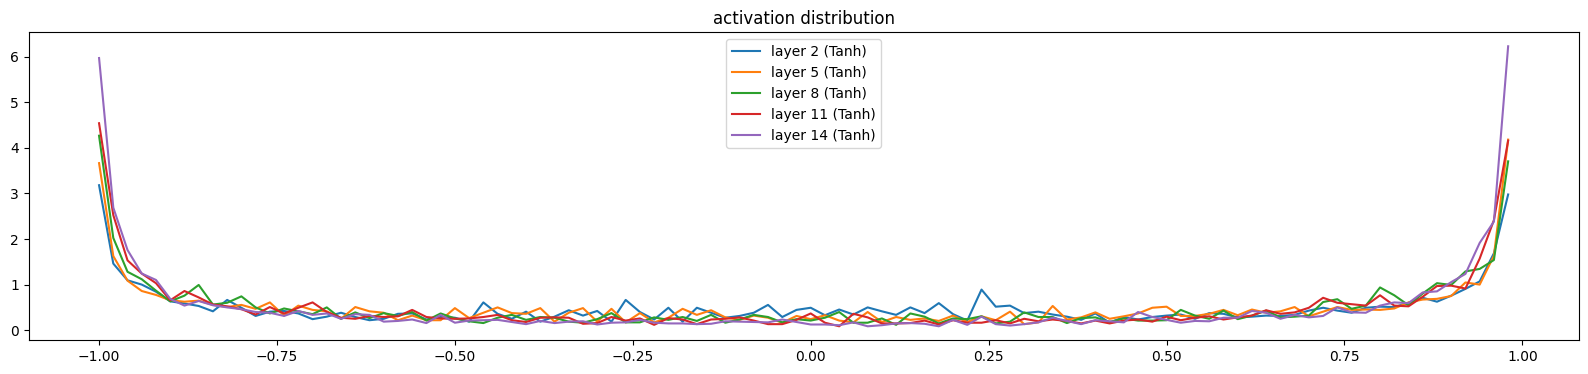

In [47]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' %
              (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')
plt.show()

layer 2 (      Tanh): mean +0.000001, std 2.798663e-03
layer 5 (      Tanh): mean +0.000008, std 2.683729e-03
layer 8 (      Tanh): mean +0.000036, std 2.557313e-03
layer 11 (      Tanh): mean +0.000038, std 2.556153e-03
layer 14 (      Tanh): mean -0.000003, std 2.392970e-03


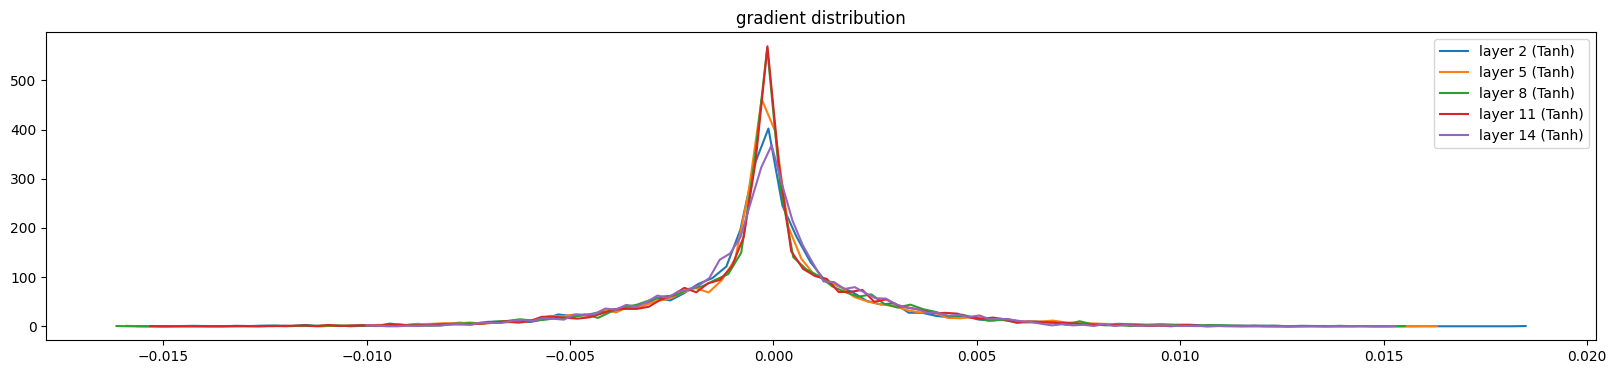

In [48]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')
plt.show()

weight   (64, 12) | mean +0.000198 | std 9.605134e-03 | grad:data ratio 8.780302e-03
weight  (48, 100) | mean +0.000042 | std 7.982627e-03 | grad:data ratio 2.145623e-02
weight (100, 100) | mean -0.000029 | std 6.017109e-03 | grad:data ratio 2.179584e-02
weight (100, 100) | mean +0.000019 | std 6.107342e-03 | grad:data ratio 2.232603e-02
weight (100, 100) | mean -0.000106 | std 6.124062e-03 | grad:data ratio 2.291116e-02
weight (100, 100) | mean +0.000084 | std 5.795981e-03 | grad:data ratio 2.298897e-02
weight  (100, 64) | mean +0.000007 | std 7.001622e-03 | grad:data ratio 2.796936e-02


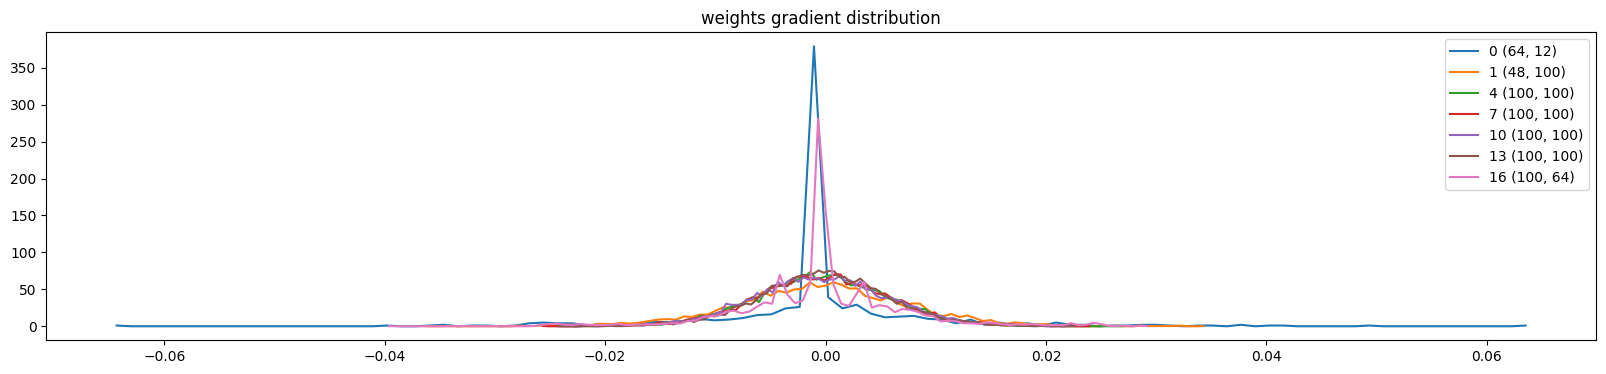

In [49]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' %
              (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')
plt.show()

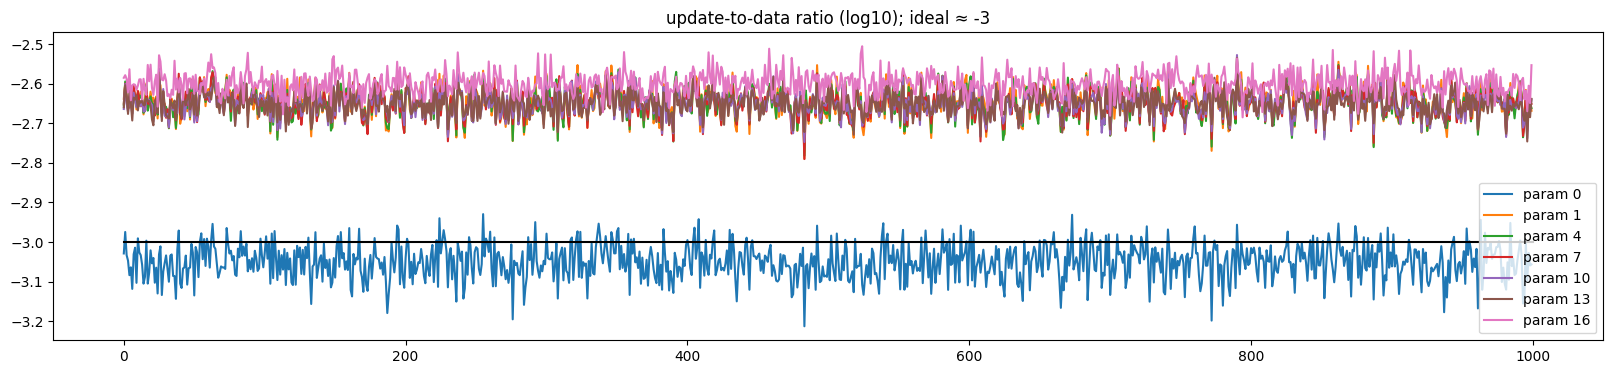

In [50]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3, -3], 'k')   # ideal ratio ≈ 1e-3
plt.legend(legends)
plt.title('update-to-data ratio (log10); ideal ≈ -3')
plt.show()

<details><summary>💡 Solution — click to expand</summary>

These three plots are the primary diagnostic tools for understanding whether a deep network is training healthily.

**Activation distribution** — all `Tanh` layers should show a roughly similar, non-degenerate spread. If any layer is all ±1, initialization or architecture is wrong. Batch normalization ensures that activations remain well-distributed at every layer.

**Gradient distribution** — gradients should not shrink systematically from the output layer back to the input layer. If the first-layer gradient std is orders of magnitude smaller than the last-layer gradient std, gradients are *vanishing*. BN prevents this by keeping activations well-scaled at every layer, which in turn keeps gradients flowing.

**Update-to-data ratio** — the ratio `(lr * grad).std() / param.std()` should be roughly 1e-3 for all weight matrices. A much smaller ratio means the parameter is barely moving; a much larger ratio means the update is destructively large.

```python
# 1. Activation distribution
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' %
              (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')
plt.show()

# 2. Gradient distribution
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')
plt.show()

# 3. Weight-gradient distribution
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' %
              (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')
plt.show()

# 4. Update-to-data ratio over time
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3, -3], 'k')   # ideal ratio ≈ 1e-3
plt.legend(legends)
plt.title('update-to-data ratio (log10); ideal ≈ -3')
plt.show()
```

</details>